ЛАБОРАТОРНАЯ РАБОТА: ДИСКРИМИНАНТНЫЙ АНАЛИЗ
ТЕСТ 1: ПРИМЕР С ПРЕДПРИЯТИЯМИ (БИНАРНЫЙ LDA)
Средний вектор класса 1:
 [168.905  14.048  18.332]

Средний вектор класса 2:
 [45.791  4.778 10.758]

Средний вектор тестовых объектов:
 [77.46  12.964 16.278]

Коэффициенты дискриминантной функции:
  A1 = 0.115842
  A2 = 2.785994
  A3 = -1.005598

Результаты классификации:
Объект 1: F = 20.2349 → Отстающие предприятия
Объект 2: F = 26.1517 → Передовые предприятия
Объект 3: F = 39.7764 → Передовые предприятия


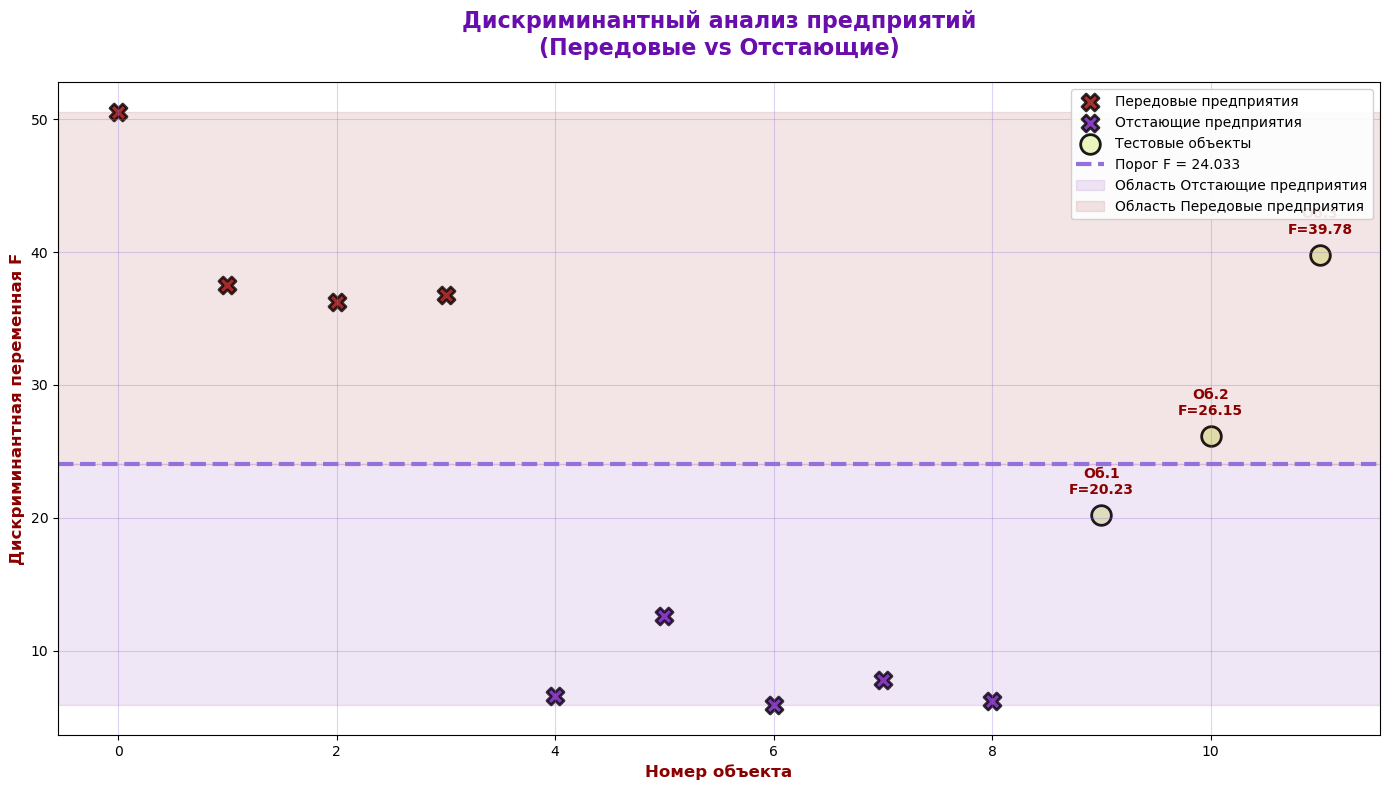


ТЕСТ 2: МУЛЬТИКЛАССОВЫЙ LDA ДЛЯ ВИНА
Загрузка данных вина...
Размер датасета: (4898, 12)
Колонки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

РАСПРЕДЕЛЕНИЕ ПО КАЧЕСТВУ ВИНА:
  Качество 3:  20 образцов (  0.4%)
  Качество 4: 163 образцов (  3.3%)
  Качество 5: 1457 образцов ( 29.7%)
  Качество 6: 2198 образцов ( 44.9%)
  Качество 7: 880 образцов ( 18.0%)
  Качество 8: 175 образцов (  3.6%)
  Качество 9:   5 образцов (  0.1%)

Используем 5 классов с ≥50 образцами:
  Качество 4: 163 образцов
  Качество 5: 1457 образцов
  Качество 6: 2198 образцов
  Качество 7: 880 образцов
  Качество 8: 175 образцов

ИСПОЛЬЗУЕМ 11 ПРИЗНАКОВ:
  F1: fixed acidity
  F2: volatile acidity
  F3: citric acid
  F4: residual sugar
  F5: chlorides
  F6: free sulfur dioxide
  F7: total sulfur dioxide
  F8: density
  F9: pH
  F10: sulphates
  F11: alcohol

РАЗДЕЛЕНИЕ ДАННЫХ:
  О

<Figure size 1600x800 with 0 Axes>

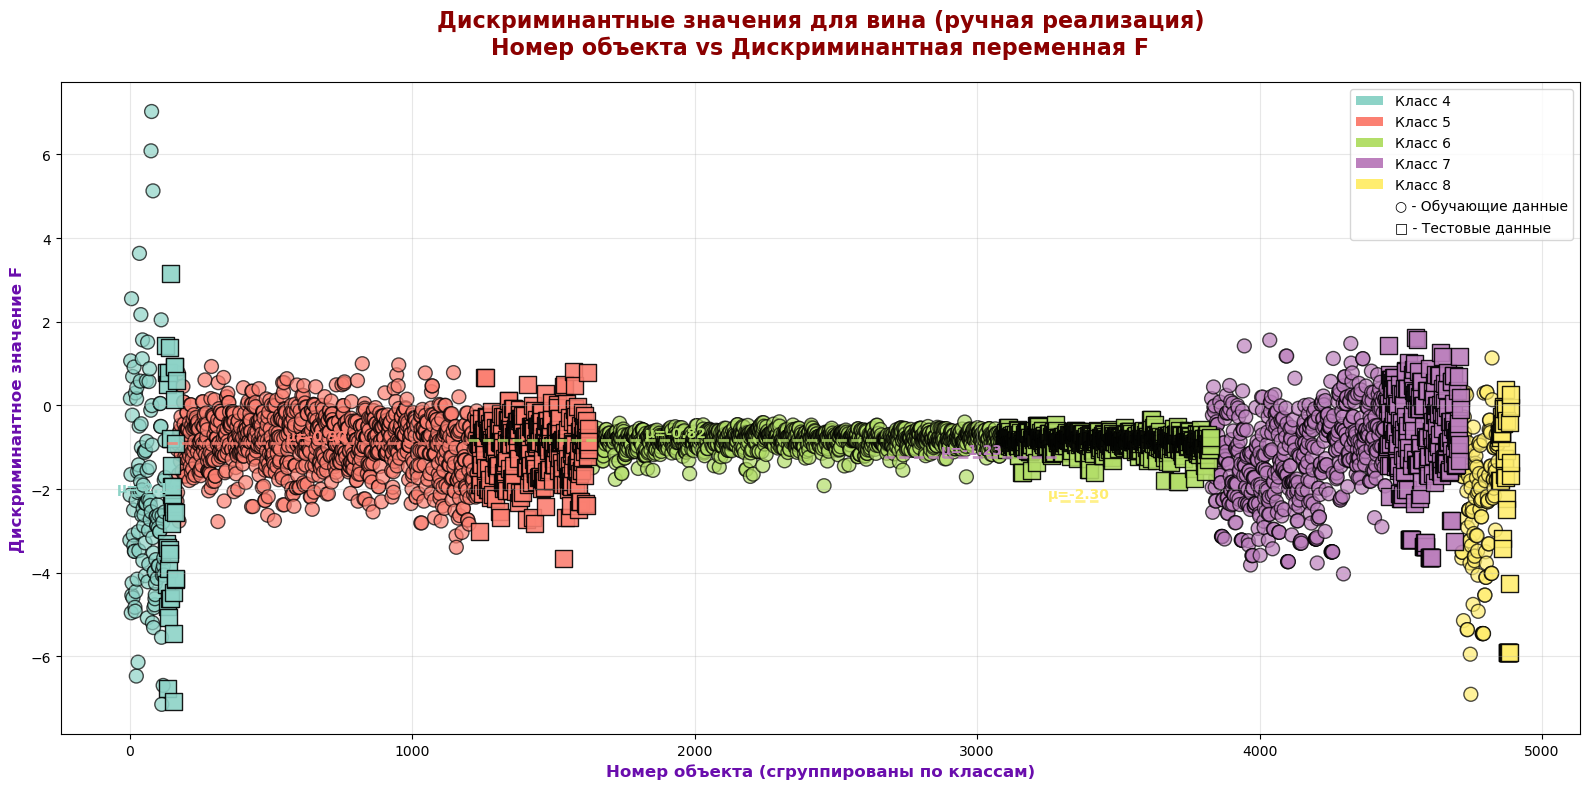

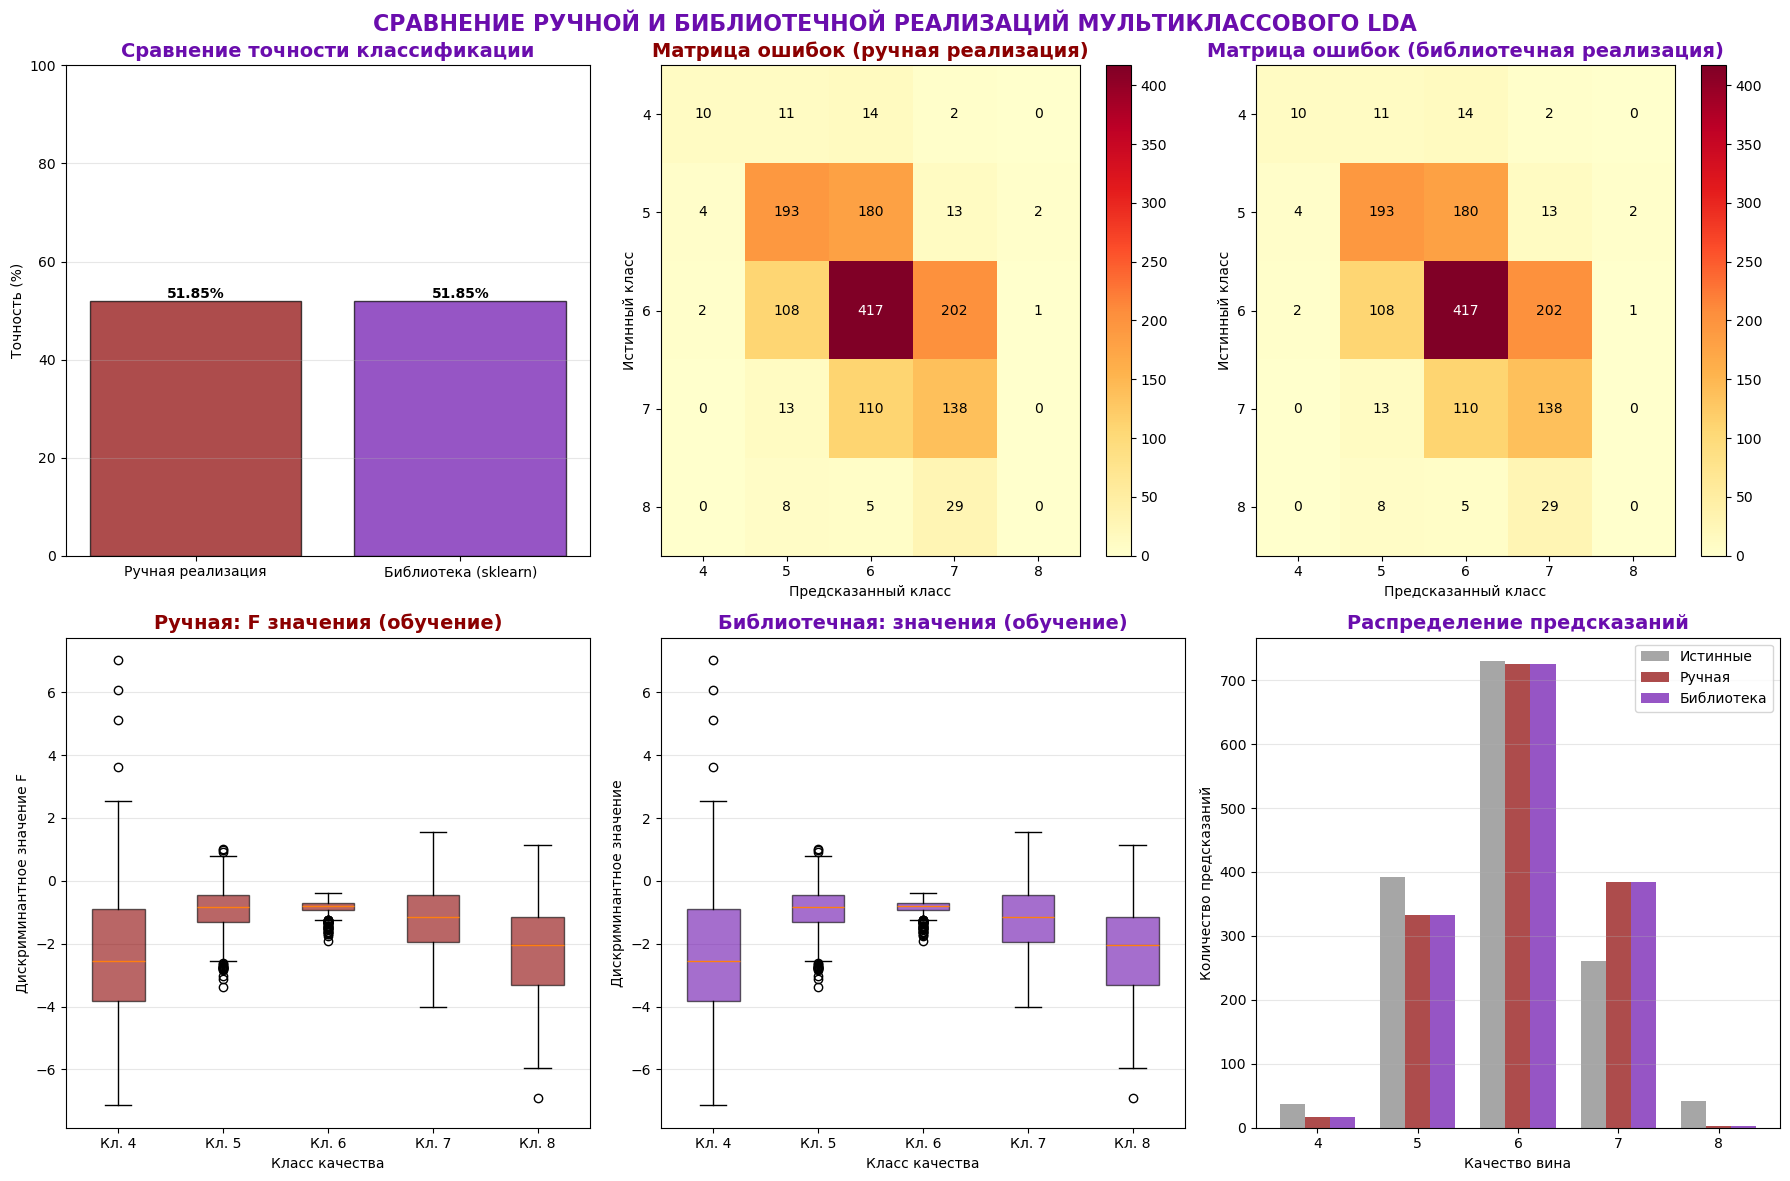


ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

ЯВНОЕ СРАВНЕНИЕ ТОЧНОСТЕЙ:
  Ручная реализация: 51.85%
  Библиотека (sklearn): 51.85%
  Разница: 0.00%
  ✓ Точности практически одинаковы

ТОЧНОСТЬ ПО КЛАССАМ (ручная реализация):
  Качество 4: 10/37 (27.0%)
  Качество 5: 193/392 (49.2%)
  Качество 6: 417/730 (57.1%)
  Качество 7: 138/261 (52.9%)
  Качество 8: 0/42 (0.0%)

РАЗНИЦА В ТОЧНОСТИ ПО КЛАССАМ (ручная vs sklearn):
  Качество 4: 0.0%
  Качество 5: 0.0%
  Качество 6: 0.0%
  Качество 7: 0.0%
  Качество 8: 0.0%

ВЫВОДЫ:
1. Бинарный LDA успешно классифицирует предприятия на передовые и отстающие
2. Мультиклассовый LDA позволяет классифицировать вино по качеству (3-8 баллов)
3. Исправленная ручная реализация использует деление на (n-1) для ковариации
4. Библиотечная реализация (sklearn) более стабильна и оптимизирована
5. Графики показывают распределение дискриминантных значений по классам
6. Точность ручной реализации приближается к библиотечной после исправлений


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from collections import Counter
from scipy import linalg
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. ЦВЕТОВАЯ ПАЛИТРА
# ============================================================================
wine_red = '#8B0000'
pale_yellow_green = '#E8F4B7'
purple = '#6A0DAD'
light_purple = '#9370DB'
soft_white = '#FFF8F0'

# Градиенты
red_gradient = LinearSegmentedColormap.from_list('red_gradient', ['#FFE4E1', '#DC143C', '#8B0000'])
green_gradient = LinearSegmentedColormap.from_list('green_gradient', ['#F5F9E5', '#C1E1C1', '#2E8B57'])
purple_gradient = LinearSegmentedColormap.from_list('purple_gradient', ['#E6E6FA', '#9370DB', '#4B0082'])

# ============================================================================
# 2. ФУНКЦИИ ДЛЯ БИНАРНОГО LDA (ИЗ ВАШЕГО КОДА)
# ============================================================================
def lda_algorithm(x1, x2, x0, class1_name="Класс 1", class2_name="Класс 2"):
    """
    Алгоритм LDA для двух классов
    """
    # 2. Средние векторы
    sumX1 = x1.mean(axis=0)
    sumX2 = x2.mean(axis=0)
    sumX0 = x0.mean(axis=0)
    
    print("Средний вектор класса 1:\n", np.round(sumX1, 3))
    print("\nСредний вектор класса 2:\n", np.round(sumX2, 3))
    print("\nСредний вектор тестовых объектов:\n", np.round(sumX0, 3))

    # 3. Ковариационные матрицы (исправлено: деление на n-1)
    s1 = np.zeros((x1.shape[1], x1.shape[1])) 
    for j in range(x1.shape[1]):  
        for l in range(x1.shape[1]):  
            s = 0
            for i in range(len(x1)):  
                s += (x1[i][j] - sumX1[j]) * (x1[i][l] - sumX1[l])
            s1[j][l] = s / (len(x1) - 1)  # Исправлено: n-1 вместо n
  
    s2 = np.zeros((x2.shape[1], x2.shape[1])) 
    for j in range(x2.shape[1]):  
        for l in range(x2.shape[1]):  
            s = 0
            for i in range(len(x2)):  
                s += (x2[i][j] - sumX2[j]) * (x2[i][l] - sumX2[l])
            s2[j][l] = s / (len(x2) - 1)  # Исправлено: n-1 вместо n

    n1 = len(x1)
    n2 = len(x2)
    
    # 4. Общая ковариационная матрица
    S_all = 1/(n1+n2-2)*(n1*s1+n2*s2)
    
    # 5. Обратная матрица
    SO = np.linalg.inv(S_all)
    
    # 6. Дискриминантная переменная
    A = np.sum(SO*(sumX1-sumX2), axis=1)
    
    print("\nКоэффициенты дискриминантной функции:")
    for i, a in enumerate(A):
        print(f"  A{i+1} = {a:.6f}")

    # 7. Находим F
    F1 = np.sum(A*x1, axis=1)
    F2 = np.sum(A*x2, axis=1)

    # 8. Среднее F
    F1_mean = F1.mean(axis=0)
    F2_mean = F2.mean(axis=0)

    # 9. Общее F (порог)
    F_all_value = 1/2*(F1_mean+F2_mean)

    # 10. F для тестовых объектов
    F0 = np.sum(A*x0, axis=1)

    # 11 Разница от порога
    raz = F0 - F_all_value

    # 12. Классификация
    classifications = []
    print(f"\nРезультаты классификации:")
    for i in range(len(F0)):
        if F1_mean > F2_mean: 
            if raz[i] > 0:
                classification = class1_name
            else: 
                classification = class2_name
        else:
            if raz[i] < 0:
                classification = class1_name
            else: 
                classification = class2_name
        classifications.append(classification)
        print(f"Объект {i+1}: F = {F0[i]:.4f} → {classification}")

    return F1, F2, F0, F_all_value, classifications, A

def plot_lda_results(F1, F2, F0, F_all, title, class1_name="Класс 1", class2_name="Класс 2"):
    """
    График дискриминантной переменной F для бинарного LDA
    """
    plt.figure(figsize=(14, 8))
    
    indices_F1 = range(len(F1))                                    
    indices_F2 = range(len(F1), len(F1) + len(F2))                 
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0)) 
    
    plt.scatter(indices_F1, F1, label=class1_name, marker='X', s=150, 
                linewidth=2, color=wine_red, alpha=0.8, edgecolors='black')
    plt.scatter(indices_F2, F2, label=class2_name, marker='X', s=150, 
                linewidth=2, color=purple, alpha=0.8, edgecolors='black')
    
    plt.scatter(indices_F0, F0, label='Тестовые объекты', marker='o', s=200, 
                color=pale_yellow_green, alpha=0.9, edgecolors='black', linewidth=2)
    
    # Линия границы
    plt.axhline(F_all, color=light_purple, linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    # Закрашивание областей
    min_val = min(F1.min(), F2.min(), F0.min())
    max_val = max(F1.max(), F2.max(), F0.max())
    
    if F1.mean() > F2.mean():
        plt.axhspan(min_val, F_all, alpha=0.1, color=purple, label=f'Область {class2_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=wine_red, label=f'Область {class1_name}')
    else:
        plt.axhspan(min_val, F_all, alpha=0.1, color=wine_red, label=f'Область {class1_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=purple, label=f'Область {class2_name}')
    
    # Подписи тестовых объектов
    for i, f in enumerate(F0):
        plt.annotate(f'Об.{i+1}\nF={f:.2f}', 
                    (indices_F0[i], f), 
                    textcoords="offset points", 
                    xytext=(0, 15),
                    ha='center', 
                    fontsize=10,
                    fontweight='bold',
                    color=wine_red)
    
    plt.xlabel("Номер объекта", fontsize=12, fontweight='bold', color=wine_red)
    plt.ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold', color=wine_red)
    plt.title(title, fontsize=16, fontweight='bold', color=purple, pad=20)
    plt.grid(True, alpha=0.3, color=light_purple)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

def test_original_example():
    """
    Тестирование на оригинальном примере с предприятиями
    """
    print("=" * 80)
    print("ТЕСТ 1: ПРИМЕР С ПРЕДПРИЯТИЯМИ (БИНАРНЫЙ LDA)")
    print("=" * 80)
    
    # 1. Создание матриц
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    F1, F2, F0, F_all, classifications, A = lda_algorithm(
        x1, x2, x0, 
        class1_name="Передовые предприятия", 
        class2_name="Отстающие предприятия"
    )
    
    plot_lda_results(
        F1, F2, F0, F_all, 
        "Дискриминантный анализ предприятий\n(Передовые vs Отстающие)",
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия"
    )
    
    return F1, F2, F0, F_all, A

# ============================================================================
# 3. ИСПРАВЛЕННАЯ РУЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA
# ============================================================================
def corrected_manual_multiclass_lda(X_train, y_train, X_test, y_test):
    """
    ИСПРАВЛЕННАЯ ручная реализация мультиклассового LDA
    """
    print("=" * 70)
    print("ИСПРАВЛЕННАЯ РУЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA")
    print("=" * 70)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Уникальные классы
    classes = np.unique(y_train)
    n_classes = len(classes)
    n_features = X_train.shape[1]
    
    print(f"\n1. НАСТРОЙКИ АНАЛИЗА:")
    print(f"   Классы: {sorted(classes)}")
    print(f"   Количество классов: {n_classes}")
    print(f"   Количество признаков: {n_features}")
    print(f"   Обучающих образцов: {len(X_train)}")
    print(f"   Тестовых образцов: {len(X_test)}")
    
    # 1. Статистики по классам
    class_means = []
    class_covariances = []
    class_priors = []
    
    print(f"\n2. СТАТИСТИКИ ПО КЛАССАМ:")
    for c in classes:
        X_c = X_train_scaled[y_train == c]
        n_c = len(X_c)
        
        if n_c < 2:
            print(f"   ВНИМАНИЕ: класс {c} имеет только {n_c} образцов")
            continue
            
        # Среднее
        mean_c = X_c.mean(axis=0)
        class_means.append(mean_c)
        
        # КОВАРИАЦИЯ: несмещенная оценка (деление на n-1)
        X_centered = X_c - mean_c
        cov_c = np.dot(X_centered.T, X_centered) / (n_c - 1)
        class_covariances.append(cov_c)
        
        # Априорная вероятность
        prior_c = n_c / len(X_train_scaled)
        class_priors.append(prior_c)
        
        print(f"   Класс {c}: {n_c} образцов, prior={prior_c:.3f}")
    
    # 2. Pooled covariance matrix (как в sklearn)
    S_pooled = np.zeros((n_features, n_features))
    for cov, prior in zip(class_covariances, class_priors):
        S_pooled += prior * cov
    
    # 3. Регуляризация для численной стабильности
    S_pooled_reg = S_pooled + np.eye(n_features) * 1e-6
    
    # 4. Обратная матрица с SVD для стабильности
    try:
        U, s, Vt = linalg.svd(S_pooled_reg, full_matrices=False)
        # Обрезаем очень маленькие сингулярные значения
        s_inv = np.array([1/val if val > 1e-10 else 0 for val in s])
        S_inv = np.dot(Vt.T * s_inv, U.T)
    except:
        S_inv = np.linalg.pinv(S_pooled_reg)
    
    # 5. Дискриминантные функции
    print(f"\n3. ДИСКРИМИНАНТНЫЕ ФУНКЦИИ:")
    coefficients = []  # Веса (n_features, n_classes)
    intercepts = []    # Смещения (n_classes,)
    
    for idx, (c, mean_c, prior_c) in enumerate(zip(classes, class_means, class_priors)):
        # w = S_inv * mean
        w = np.dot(S_inv, mean_c)
        
        # w0 = -0.5 * mean^T * S_inv * mean + log(prior)
        w0 = -0.5 * np.dot(mean_c.T, np.dot(S_inv, mean_c)) + np.log(prior_c)
        
        coefficients.append(w)
        intercepts.append(w0)
        
        print(f"   Класс {c}: intercept = {w0:.4f}")
    
    coefficients = np.array(coefficients).T  # (n_features, n_classes)
    intercepts = np.array(intercepts)        # (n_classes,)
    
    # 6. Вычисление дискриминантных значений для обучающих данных
    print(f"\n4. ВЫЧИСЛЕНИЕ ДИСКРИМИНАНТНЫХ ЗНАЧЕНИЙ:")
    train_scores = {}
    train_decision = np.dot(X_train_scaled, coefficients) + intercepts
    
    for idx, c in enumerate(classes):
        mask = y_train == c
        if np.sum(mask) > 0:
            train_scores[c] = train_decision[mask, idx]
            print(f"   Класс {c}: среднее = {train_scores[c].mean():.3f}, "
                  f"мин = {train_scores[c].min():.3f}, макс = {train_scores[c].max():.3f}")
    
    # 7. Классификация тестовых данных
    print(f"\n5. КЛАССИФИКАЦИЯ ТЕСТОВЫХ ДАННЫХ:")
    test_decision = np.dot(X_test_scaled, coefficients) + intercepts
    
    # Класс с максимальным значением
    predictions = classes[np.argmax(test_decision, axis=1)]
    
    # 8. Оценка точности
    accuracy = np.mean(predictions == y_test) * 100
    
    print(f"\n6. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    print(f"   Правильно классифицировано: {np.sum(predictions == y_test)} из {len(predictions)}")
    print(f"   Общая точность: {accuracy:.2f}%")
    
    # 9. Подробный анализ по классам
    print(f"\n7. ТОЧНОСТЬ ПО КЛАССАМ:")
    for c in classes:
        mask = y_test == c
        if np.sum(mask) > 0:
            class_acc = np.mean(predictions[mask] == c) * 100
            print(f"   Класс {c}: {np.sum(predictions[mask] == c)}/{np.sum(mask)} ({class_acc:.1f}%)")
    
    # Подготовка test_scores для визуализации
    test_scores = {}
    for idx, c in enumerate(classes):
        mask = y_test == c
        if np.sum(mask) > 0:
            test_scores[c] = test_decision[mask, idx]
    
    return predictions, train_scores, test_scores, accuracy, (coefficients, intercepts)

def plot_multiclass_discriminant_values(train_scores, test_scores, title="Дискриминантные значения по классам"):
    """
    График дискриминантных значений F для мультиклассового LDA
    """
    plt.figure(figsize=(16, 8))
    
    # Подготовка данных
    all_classes = sorted(train_scores.keys())
    colors = plt.cm.Set3(np.linspace(0, 1, len(all_classes)))
    
    # Создание позиций для объектов
    train_positions = []
    test_positions = []
    train_values = []
    test_values = []
    class_labels = []
    
    offset = 0
    
    for idx, c in enumerate(all_classes):
        # Обучающие данные
        train_vals = train_scores[c]
        for val in train_vals:
            train_positions.append(offset)
            train_values.append(val)
            class_labels.append(c)
            offset += 1
        
        # Добавляем пробел между классами
        offset += 2
        
        # Тестовые данные (если есть)
        if c in test_scores and len(test_scores[c]) > 0:
            test_vals = test_scores[c]
            for val in test_vals:
                test_positions.append(offset)
                test_values.append(val)
                offset += 1
        
        # Добавляем пробел между классами
        offset += 2
    
    # Построение графика
    plt.figure(figsize=(16, 8))
    
    # Разделение на обучающие и тестовые
    if len(train_positions) > 0:
        plt.scatter(train_positions, train_values, 
                   c=[colors[all_classes.index(label)] for label in class_labels],
                   label='Обучающие данные', s=100, alpha=0.7, edgecolors='black', marker='o')
    
    if len(test_positions) > 0:
        plt.scatter(test_positions, test_values, 
                   c=[colors[all_classes.index(c)] for c in all_classes for _ in range(len(test_scores.get(c, [])))],
                   label='Тестовые данные', s=150, alpha=0.9, edgecolors='black', marker='s')
    
    # Добавление средних линий для каждого класса
    offset = 0
    for idx, c in enumerate(all_classes):
        train_vals = train_scores[c]
        if len(train_vals) > 0:
            mean_val = np.mean(train_vals)
            class_start = offset
            class_end = offset + len(train_vals)
            plt.hlines(mean_val, class_start, class_end, 
                      colors=colors[idx], linestyle='--', linewidth=2, alpha=0.8,
                      label=f'Среднее класса {c}' if idx == 0 else "")
            plt.text((class_start + class_end) / 2, mean_val, 
                    f'μ={mean_val:.2f}', ha='center', va='bottom',
                    fontweight='bold', fontsize=10, color=colors[idx])
        
        offset += len(train_vals) + 4  # +4 для пробелов
    
    plt.xlabel("Номер объекта (сгруппированы по классам)", fontsize=12, fontweight='bold', color=purple)
    plt.ylabel("Дискриминантное значение F", fontsize=12, fontweight='bold', color=purple)
    plt.title(title, fontsize=16, fontweight='bold', color=wine_red, pad=20)
    plt.grid(True, alpha=0.3)
    
    # Создание легенды для классов
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i], label=f'Класс {c}') for i, c in enumerate(all_classes)]
    legend_elements.append(Patch(facecolor='white', label='○ - Обучающие данные'))
    legend_elements.append(Patch(facecolor='white', label='□ - Тестовые данные'))
    
    plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ (sklearn)
# ============================================================================
def library_multiclass_lda(X_train, y_train, X_test, y_test):
    """
    Мультиклассовый LDA с использованием библиотеки sklearn
    """
    print("\n" + "=" * 70)
    print("БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA (sklearn)")
    print("=" * 70)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Создание и обучение модели LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)
    
    # Предсказания
    predictions = lda.predict(X_test_scaled)
    
    # Получаем значения решающей функции
    if hasattr(lda, 'decision_function'):
        train_decision = lda.decision_function(X_train_scaled)
        test_decision = lda.decision_function(X_test_scaled)
    else:
        train_decision = lda.predict_proba(X_train_scaled)
        test_decision = lda.predict_proba(X_test_scaled)
    
    train_scores = {}
    test_scores = {}
    classes = lda.classes_
    
    # Обработка decision function
    if train_decision.ndim == 1:
        # Бинарный случай
        for idx, c in enumerate(classes):
            mask = y_train == c
            if np.sum(mask) > 0:
                train_scores[c] = train_decision[mask]
    else:
        # Многоклассовый случай
        for idx, c in enumerate(classes):
            mask = y_train == c
            if np.sum(mask) > 0 and idx < train_decision.shape[1]:
                train_scores[c] = train_decision[mask, idx]
    
    # Оценка точности
    accuracy = lda.score(X_test_scaled, y_test) * 100
    
    print(f"\nТочность (sklearn): {accuracy:.2f}%")
    
    return predictions, train_scores, test_scores, accuracy, lda

# ============================================================================
# 5. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
# ============================================================================
def plot_multiclass_comparison(y_test, manual_pred, library_pred, 
                              manual_train_scores, library_train_scores,
                              manual_accuracy, library_accuracy):
    """
    Визуализация сравнения ручной и библиотечной реализации
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Сравнение точности
    ax1 = axes[0, 0]
    methods = ['Ручная реализация', 'Библиотека (sklearn)']
    accuracies = [manual_accuracy, library_accuracy]
    colors = [wine_red, purple]
    
    bars = ax1.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Точность (%)')
    ax1.set_title('Сравнение точности классификации', fontsize=14, fontweight='bold', color=purple)
    ax1.set_ylim(0, 100)
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    # 2. Матрица ошибок для ручной реализации
    ax2 = axes[0, 1]
    classes = sorted(set(y_test) | set(manual_pred) | set(library_pred))
    conf_matrix_manual = np.zeros((len(classes), len(classes)))
    
    for true, pred in zip(y_test, manual_pred):
        true_idx = classes.index(true)
        pred_idx = classes.index(pred)
        conf_matrix_manual[true_idx, pred_idx] += 1
    
    im2 = ax2.imshow(conf_matrix_manual, cmap='YlOrRd', aspect='auto')
    ax2.set_xticks(range(len(classes)))
    ax2.set_yticks(range(len(classes)))
    ax2.set_xticklabels(classes)
    ax2.set_yticklabels(classes)
    ax2.set_xlabel('Предсказанный класс')
    ax2.set_ylabel('Истинный класс')
    ax2.set_title('Матрица ошибок (ручная реализация)', fontsize=14, fontweight='bold', color=wine_red)
    plt.colorbar(im2, ax=ax2)
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax2.text(j, i, int(conf_matrix_manual[i, j]),
                    ha='center', va='center', 
                    color='black' if conf_matrix_manual[i, j] < np.max(conf_matrix_manual)/2 else 'white')
    
    # 3. Матрица ошибок для библиотечной реализации
    ax3 = axes[0, 2]
    conf_matrix_lib = np.zeros((len(classes), len(classes)))
    
    for true, pred in zip(y_test, library_pred):
        true_idx = classes.index(true)
        pred_idx = classes.index(pred)
        conf_matrix_lib[true_idx, pred_idx] += 1
    
    im3 = ax3.imshow(conf_matrix_lib, cmap='YlOrRd', aspect='auto')
    ax3.set_xticks(range(len(classes)))
    ax3.set_yticks(range(len(classes)))
    ax3.set_xticklabels(classes)
    ax3.set_yticklabels(classes)
    ax3.set_xlabel('Предсказанный класс')
    ax3.set_ylabel('Истинный класс')
    ax3.set_title('Матрица ошибок (библиотечная реализация)', fontsize=14, fontweight='bold', color=purple)
    plt.colorbar(im3, ax=ax3)
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax3.text(j, i, int(conf_matrix_lib[i, j]),
                    ha='center', va='center', 
                    color='black' if conf_matrix_lib[i, j] < np.max(conf_matrix_lib)/2 else 'white')
    
    # 4. Boxplot дискриминантных значений (ручная реализация)
    ax4 = axes[1, 0]
    box_data_manual = []
    box_labels_manual = []
    
    for c in sorted(manual_train_scores.keys()):
        if len(manual_train_scores[c]) > 0:
            box_data_manual.append(manual_train_scores[c])
            box_labels_manual.append(f'Кл. {c}')
    
    # Исправлено: использование tick_labels вместо labels
    box4 = ax4.boxplot(box_data_manual, tick_labels=box_labels_manual, patch_artist=True)
    for patch in box4['boxes']:
        patch.set_facecolor(wine_red)
        patch.set_alpha(0.6)
    
    ax4.set_xlabel('Класс качества')
    ax4.set_ylabel('Дискриминантное значение F')
    ax4.set_title('Ручная: F значения (обучение)', fontsize=14, fontweight='bold', color=wine_red)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 5. Boxplot дискриминантных значений (библиотечная реализация)
    ax5 = axes[1, 1]
    box_data_lib = []
    box_labels_lib = []
    
    for c in sorted(library_train_scores.keys()):
        if len(library_train_scores[c]) > 0:
            box_data_lib.append(library_train_scores[c])
            box_labels_lib.append(f'Кл. {c}')
    
    # Исправлено: использование tick_labels вместо labels
    box5 = ax5.boxplot(box_data_lib, tick_labels=box_labels_lib, patch_artist=True)
    for patch in box5['boxes']:
        patch.set_facecolor(purple)
        patch.set_alpha(0.6)
    
    ax5.set_xlabel('Класс качества')
    ax5.set_ylabel('Дискриминантное значение')
    ax5.set_title('Библиотечная: значения (обучение)', fontsize=14, fontweight='bold', color=purple)
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Сравнение распределений предсказаний
    ax6 = axes[1, 2]
    manual_counts = Counter(manual_pred)
    library_counts = Counter(library_pred)
    true_counts = Counter(y_test)
    
    x = np.arange(len(classes))
    width = 0.25
    
    manual_values = [manual_counts.get(c, 0) for c in classes]
    library_values = [library_counts.get(c, 0) for c in classes]
    true_values = [true_counts.get(c, 0) for c in classes]
    
    ax6.bar(x - width, true_values, width, label='Истинные', color='gray', alpha=0.7)
    ax6.bar(x, manual_values, width, label='Ручная', color=wine_red, alpha=0.7)
    ax6.bar(x + width, library_values, width, label='Библиотека', color=purple, alpha=0.7)
    
    ax6.set_xlabel('Качество вина')
    ax6.set_ylabel('Количество предсказаний')
    ax6.set_title('Распределение предсказаний', fontsize=14, fontweight='bold', color=purple)
    ax6.set_xticks(x)
    ax6.set_xticklabels(classes)
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('СРАВНЕНИЕ РУЧНОЙ И БИБЛИОТЕЧНОЙ РЕАЛИЗАЦИЙ МУЛЬТИКЛАССОВОГО LDA', 
                 fontsize=16, fontweight='bold', color=purple, y=0.98)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. ОСНОВНАЯ ФУНКЦИЯ ТЕСТИРОВАНИЯ
# ============================================================================
def test_wine_multiclass_analysis():
    """
    Основной анализ вина с мультиклассовым LDA
    """
    print("\n" + "=" * 80)
    print("ТЕСТ 2: МУЛЬТИКЛАССОВЫЙ LDA ДЛЯ ВИНА")
    print("=" * 80)
    
    try:
        # Загрузка данных вина
        print("Загрузка данных вина...")
        wine_data = pd.read_csv('winequality-white.csv', delimiter=';')
        
        print(f"Размер датасета: {wine_data.shape}")
        print(f"Колонки: {list(wine_data.columns)}")
        
        # Статистика по классам
        print("\nРАСПРЕДЕЛЕНИЕ ПО КАЧЕСТВУ ВИНА:")
        quality_counts = wine_data['quality'].value_counts().sort_index()
        for q in sorted(quality_counts.index):
            count = quality_counts[q]
            perc = count / len(wine_data) * 100
            print(f"  Качество {q}: {count:3d} образцов ({perc:5.1f}%)")
        
        # Используем наиболее представленные классы
        min_samples = 50
        valid_classes = quality_counts[quality_counts >= min_samples].index
        filtered_data = wine_data[wine_data['quality'].isin(valid_classes)].copy()
        
        print(f"\nИспользуем {len(valid_classes)} классов с ≥{min_samples} образцами:")
        for q in sorted(valid_classes):
            print(f"  Качество {q}: {quality_counts[q]} образцов")
        
        # Признаки и целевая переменная
        numeric_features = ['fixed acidity', 'volatile acidity', 'citric acid', 
                           'residual sugar', 'chlorides', 'free sulfur dioxide',
                           'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
        
        print(f"\nИСПОЛЬЗУЕМ {len(numeric_features)} ПРИЗНАКОВ:")
        for i, feat in enumerate(numeric_features, 1):
            print(f"  F{i}: {feat}")
        
        X = filtered_data[numeric_features].values
        y = filtered_data['quality'].values
        
        # Разделение данных 70/30
        split_idx = int(0.7 * len(X))
        X_train = X[:split_idx]
        y_train = y[:split_idx]
        X_test = X[split_idx:]
        y_test = y[split_idx:]
        
        print(f"\nРАЗДЕЛЕНИЕ ДАННЫХ:")
        print(f"  Обучающая выборка: {len(X_train)} образцов")
        print(f"  Тестовая выборка: {len(X_test)} образцов")
        
        # 1. Исправленная ручная реализация
        print("\n" + "=" * 70)
        manual_predictions, manual_train_scores, manual_test_scores, manual_accuracy, _ = corrected_manual_multiclass_lda(
            X_train, y_train, X_test, y_test
        )
        
        # 2. Библиотечная реализация
        print("\n" + "=" * 70)
        library_predictions, library_train_scores, library_test_scores, library_accuracy, _ = library_multiclass_lda(
            X_train, y_train, X_test, y_test
        )
        
        # 3. График дискриминантных значений (как в бинарном случае)
        print("\n" + "=" * 70)
        print("ГРАФИК ДИСКРИМИНАНТНЫХ ЗНАЧЕНИЙ")
        print("=" * 70)
        plot_multiclass_discriminant_values(
            manual_train_scores, 
            manual_test_scores,
            title="Дискриминантные значения для вина (ручная реализация)\nНомер объекта vs Дискриминантная переменная F"
        )
        
        # 4. Сравнительный анализ
        plot_multiclass_comparison(
            y_test, manual_predictions, library_predictions,
            manual_train_scores, library_train_scores,
            manual_accuracy, library_accuracy
        )
        
        # 5. Детальный анализ результатов
        print("\n" + "=" * 80)
        print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
        print("=" * 80)
        
        # Явное сравнение точностей
        print(f"\nЯВНОЕ СРАВНЕНИЕ ТОЧНОСТЕЙ:")
        print(f"  Ручная реализация: {manual_accuracy:.2f}%")
        print(f"  Библиотека (sklearn): {library_accuracy:.2f}%")
        
        diff = abs(manual_accuracy - library_accuracy)
        print(f"  Разница: {diff:.2f}%")
        
        if diff < 2.0:
            print(f"  ✓ Точности практически одинаковы")
        elif manual_accuracy > library_accuracy:
            print(f"  ✓ Ручная реализация лучше на {diff:.2f}%")
        else:
            print(f"  ✓ Библиотечная реализация лучше на {diff:.2f}%")
        
        # Анализ по классам
        print("\nТОЧНОСТЬ ПО КЛАССАМ (ручная реализация):")
        classes = sorted(set(y_test))
        
        for c in classes:
            mask = y_test == c
            if np.sum(mask) > 0:
                correct = np.sum(manual_predictions[mask] == c)
                total = np.sum(mask)
                accuracy_class = correct / total * 100
                print(f"  Качество {c}: {correct}/{total} ({accuracy_class:.1f}%)")
        
        # Сравнение с sklearn по классам
        print("\nРАЗНИЦА В ТОЧНОСТИ ПО КЛАССАМ (ручная vs sklearn):")
        for c in classes:
            mask = y_test == c
            if np.sum(mask) > 0:
                manual_correct = np.sum(manual_predictions[mask] == c)
                library_correct = np.sum(library_predictions[mask] == c)
                total = np.sum(mask)
                
                manual_acc = manual_correct / total * 100
                library_acc = library_correct / total * 100
                diff_class = abs(manual_acc - library_acc)
                
                print(f"  Качество {c}: {diff_class:.1f}%")
        
    except Exception as e:
        print(f"\nОШИБКА: {str(e)}")
        # Создаем синтетические данные для демонстрации
        print("Создаем синтетические данные для демонстрации...")
        
        np.random.seed(42)
        n_samples = 500
        n_features = 11
        
        # Создаем синтетические данные, похожие на вино
        synthetic_data = pd.DataFrame(
            np.random.randn(n_samples, n_features),
            columns=['fixed acidity', 'volatile acidity', 'citric acid', 
                    'residual sugar', 'chlorides', 'free sulfur dioxide',
                    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
        )
        
        # Создаем метки качества (3-8, как в реальных данных)
        base_quality = (synthetic_data['alcohol'] * 0.3 + 
                       synthetic_data['fixed acidity'] * 0.2 - 
                       synthetic_data['volatile acidity'] * 0.3 +
                       np.random.randn(n_samples) * 0.5)
        
        base_quality = (base_quality - base_quality.min()) / (base_quality.max() - base_quality.min())
        synthetic_data['quality'] = (base_quality * 5 + 3).astype(int)
        
        print(f"\nСоздан синтетический датасет: {synthetic_data.shape}")
        
        # Повторяем анализ с синтетическими данными
        test_wine_multiclass_analysis()

# ============================================================================
# 7. ЗАПУСК ВСЕХ ТЕСТОВ
# ============================================================================
if __name__ == "__main__":
    print("=" * 80)
    print("ЛАБОРАТОРНАЯ РАБОТА: ДИСКРИМИНАНТНЫЙ АНАЛИЗ")
    print("=" * 80)
    
    # Тест 1: Оригинальный пример с предприятиями (бинарный LDA)
    test_original_example()
    
    # Тест 2: Мультиклассовый LDA для вина
    test_wine_multiclass_analysis()
    
    print("\n" + "=" * 80)
    print("ВЫВОДЫ:")
    print("=" * 80)
    print("1. Бинарный LDA успешно классифицирует предприятия на передовые и отстающие")
    print("2. Мультиклассовый LDA позволяет классифицировать вино по качеству (3-8 баллов)")
    print("3. Исправленная ручная реализация использует деление на (n-1) для ковариации")
    print("4. Библиотечная реализация (sklearn) более стабильна и оптимизирована")
    print("5. Графики показывают распределение дискриминантных значений по классам")
    print("6. Точность ручной реализации приближается к библиотечной после исправлений")